In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\zepto-data-ai-platform\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [6]:
df.to_csv("titanic.csv", index=False)

print("Saved: titanic.csv")

Saved: titanic.csv


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("Shape:", df.shape)

Shape: (891, 15)


In [10]:
missing_percent = df.isna().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [11]:
print("Shape:", df.shape)
print(missing_percent)

Shape: (891, 15)
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [10]:
# Keep the original dataset unchanged for reference.
cleaned_df = df.copy()

# 1. Drop the high-missing column.
cleaned_df = cleaned_df.drop(columns=["deck"])

# 2. Impute age using the median.
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

# 3. Drop rows with missing values in columns under the 5% threshold.
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])

print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)

Original shape: (891, 15)
Cleaned shape: (889, 14)


In [13]:
cleaned_df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved.")
print("Rows:", len(cleaned_df))
print("Columns:", len(cleaned_df.columns))

Cleaned Titanic dataset saved.
Rows: 889
Columns: 14


In [14]:
cleaned_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


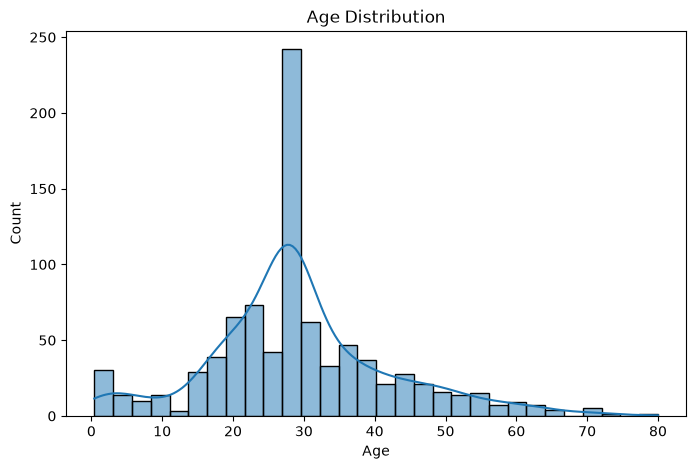

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution Interpretation

The age distribution is concentrated mainly around the late 20s to early 30s, with the highest number of observations around age 28. The distribution also contains fewer observations at very young and older ages, creating a longer tail toward higher ages. This indicates that most passengers in the cleaned Titanic dataset were young to middle-aged adults.

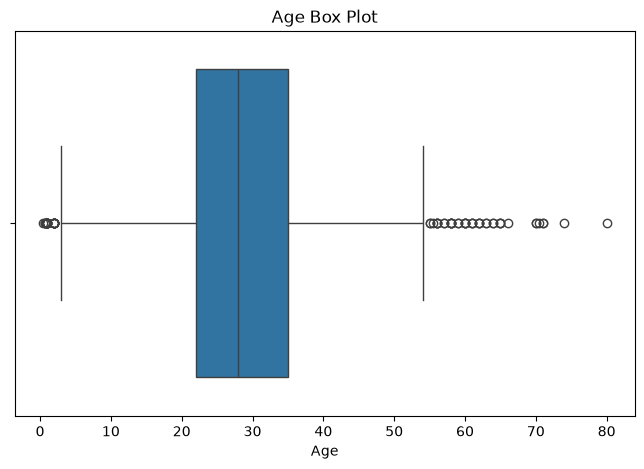

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=cleaned_df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

### Age Box Plot Interpretation

The box plot shows that the middle 50% of passenger ages lies approximately between 22 and 35 years. There are some age values outside the main range, indicating the presence of potential outliers. The distribution also shows that passenger ages extend from very young children to older adults.

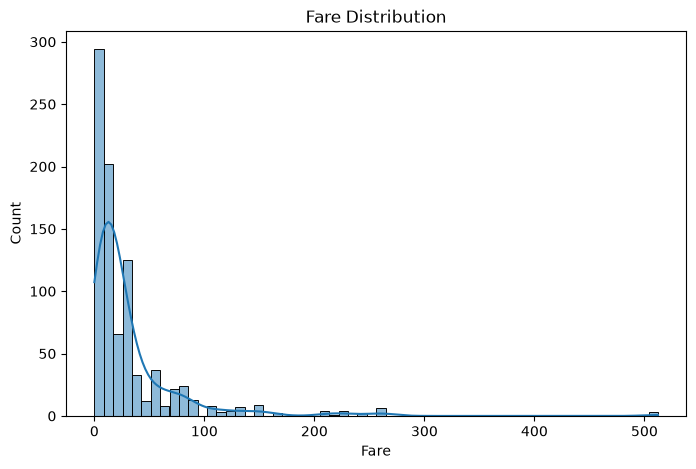

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

### Fare Distribution Interpretation

The fare distribution is strongly right-skewed, with most passengers concentrated at lower fare values and a smaller number of passengers paying much higher fares. The long right tail shows the presence of relatively expensive fares. This pattern is consistent with the mean fare (32.10) being higher than the median (14.45) and the mode (8.05).

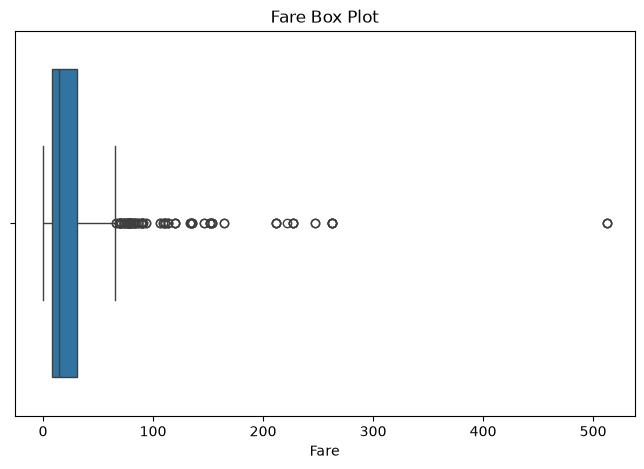

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=cleaned_df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

### Fare Box Plot Interpretation

The fare box plot shows that most passengers paid relatively low fares, while several observations extend far beyond the upper whisker. These points represent potential high-fare outliers and indicate a strongly right-skewed fare distribution. The large spread toward higher fare values is consistent with the long right tail observed in the fare histogram.

In [19]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return len(outliers), q1, q3, iqr, lower_bound, upper_bound


age_result = iqr_outlier_count(cleaned_df["age"])
fare_result = iqr_outlier_count(cleaned_df["fare"])

print("AGE")
print("Outliers:", age_result[0])
print("Q1:", age_result[1])
print("Q3:", age_result[2])
print("IQR:", age_result[3])
print("Lower bound:", age_result[4])
print("Upper bound:", age_result[5])

print("\nFARE")
print("Outliers:", fare_result[0])
print("Q1:", fare_result[1])
print("Q3:", fare_result[2])
print("IQR:", fare_result[3])
print("Lower bound:", fare_result[4])
print("Upper bound:", fare_result[5])

AGE
Outliers: 65
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5

FARE
Outliers: 114
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563


In [20]:
fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode().iloc[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


### Fare Distribution Interpretation

The fare distribution is right-skewed because the mean fare (32.10) is greater than the median (14.45), and the median is greater than the mode (8.05). This indicates that a smaller number of passengers paid much higher fares, which pulled the mean upward.

In [21]:
male_survival = cleaned_df.loc[
    cleaned_df["sex"] == "male",
    "survived"
].mean()

female_survival = cleaned_df.loc[
    cleaned_df["sex"] == "female",
    "survived"
].mean()

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154


### Survival Rate by Sex Interpretation

The survival rate differs substantially by sex. About 74.04% of female passengers survived, compared with about 18.89% of male passengers. This shows a much higher observed survival rate among female passengers in the cleaned Titanic dataset.

In [22]:
for pclass in sorted(cleaned_df["pclass"].unique()):
    rate = cleaned_df.loc[
        cleaned_df["pclass"] == pclass,
        "survived"
    ].mean()

    print(f"Pclass {pclass} survival rate:", rate)

Pclass 1 survival rate: 0.6261682242990654
Pclass 2 survival rate: 0.47282608695652173
Pclass 3 survival rate: 0.24236252545824846


### Survival Rate by Passenger Class Interpretation

The observed survival rate varies across passenger classes. Passengers in 1st class had a survival rate of about 62.62%, compared with 47.28% for 2nd class and 24.24% for 3rd class. The results show a clear decrease in observed survival rate as passenger class moves from 1st to 3rd class.

In [23]:
for sex in sorted(cleaned_df["sex"].unique()):
    for pclass in sorted(cleaned_df["pclass"].unique()):
        mask = (
            (cleaned_df["sex"] == sex)
            & (cleaned_df["pclass"] == pclass)
        )

        rate = cleaned_df.loc[mask, "survived"].mean()

        print(
            f"{sex}, Pclass {pclass}: "
            f"survival rate = {rate:.4f}"
        )

female, Pclass 1: survival rate = 0.9674
female, Pclass 2: survival rate = 0.9211
female, Pclass 3: survival rate = 0.5000
male, Pclass 1: survival rate = 0.3689
male, Pclass 2: survival rate = 0.1574
male, Pclass 3: survival rate = 0.1354


### Survival Rate by Sex and Passenger Class Interpretation

The survival rate varies across both sex and passenger class. Female passengers had higher observed survival rates within every class, with approximately 96.74% in 1st class, 92.11% in 2nd class, and 50.00% in 3rd class. Among male passengers, the observed survival rates were about 36.89% in 1st class, 15.74% in 2nd class, and 13.54% in 3rd class. This shows that the combination of sex and passenger class provides a more detailed view of survival patterns than either variable alone.

In [11]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = cleaned_df[corr_columns].corr()

print(corr_matrix)

corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Two strongest unique correlations:")
print(corr_pairs.head(2))

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000
Two strongest unique correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


### Correlation Interpretation

The strongest correlation is between `pclass` and `fare`, with a correlation of approximately -0.55. This negative relationship indicates that passenger class and fare tend to move in opposite directions in the numeric coding, with higher passenger-class codes generally associated with lower fares.

The second strongest correlation is between `sibsp` and `parch`, with a correlation of approximately 0.41. This positive relationship suggests that passengers traveling with siblings or spouses also tended to have parents or children recorded in the dataset.

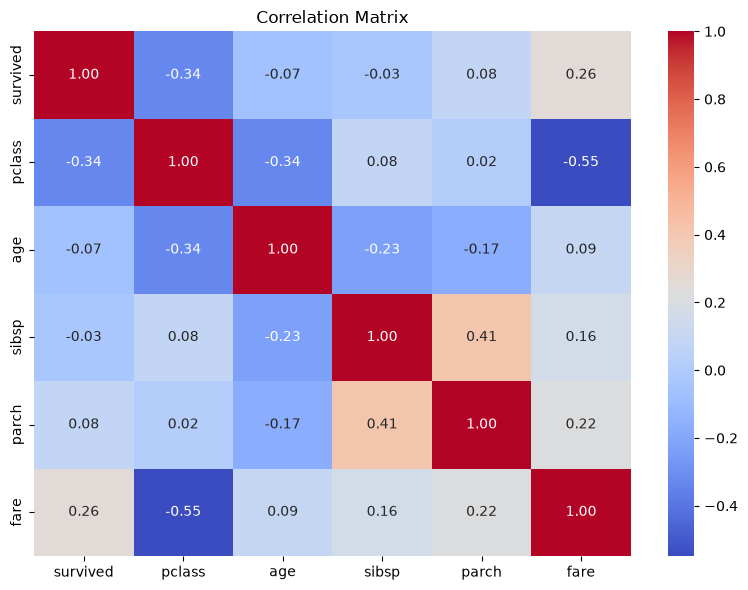

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [26]:
corr_pairs = (
    corr_matrix
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Strongest correlations:")
print(corr_pairs.head(4))

Strongest correlations:
pclass  fare     -0.548193
fare    pclass   -0.548193
sibsp   parch     0.414542
parch   sibsp     0.414542
dtype: float64


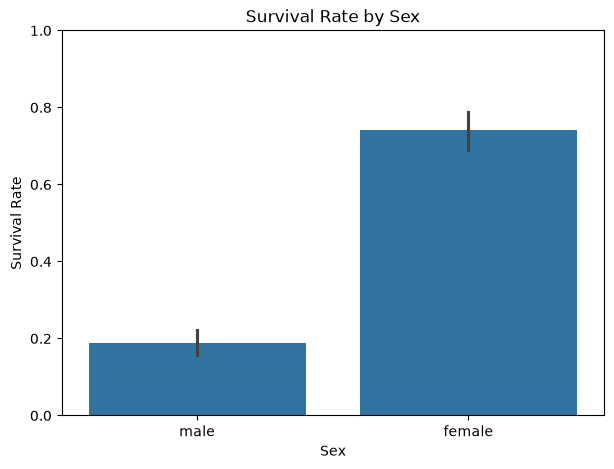

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=cleaned_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.show()

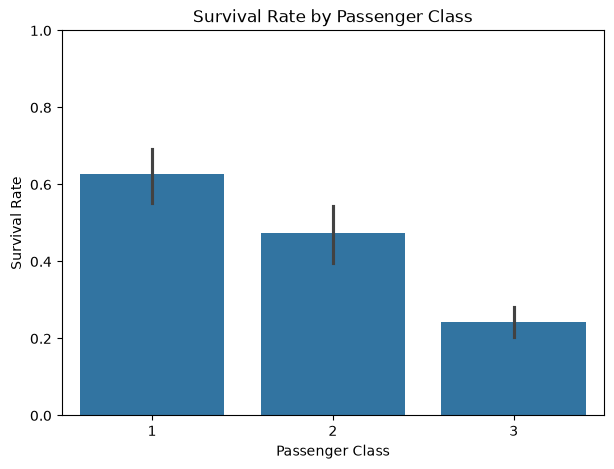

In [28]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=cleaned_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.show()

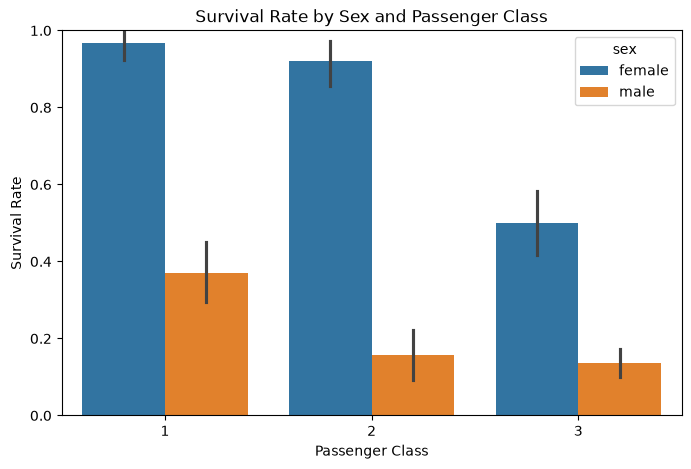

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cleaned_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.show()

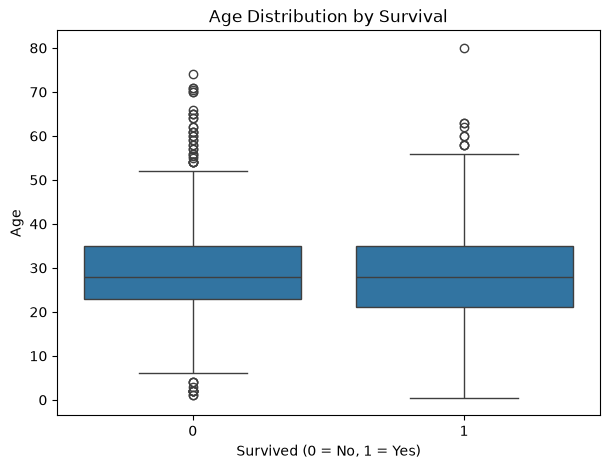

In [30]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

### Age Distribution by Survival Interpretation

The box plot shows the age distribution of passengers who survived and those who did not survive. The median ages of the two groups are relatively close, although the distributions show variation and some extreme age values. This suggests that age alone does not clearly separate the two survival groups, but it can still contribute useful information when considered together with other variables.

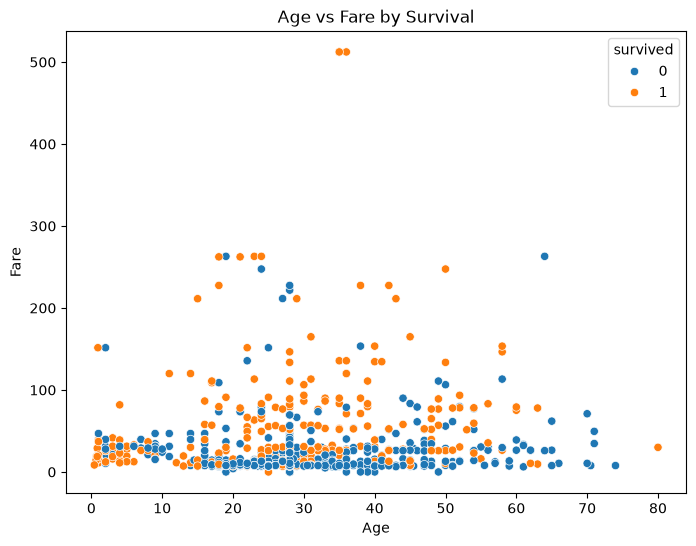

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Age vs Fare by Survival Interpretation

The scatter plot shows the relationship between passenger age, fare, and survival status. Survivors and non-survivors are distributed across different age and fare ranges, while several high-fare observations appear at different ages. This chart helps examine survival patterns using age and fare together rather than considering each variable separately.

In [31]:
age_summary = cleaned_df.groupby("survived")["age"].agg(
    ["mean", "median", "min", "max"]
)

print(age_summary)

               mean  median   min   max
survived                               
0         30.028233    28.0  1.00  74.0
1         28.163735    28.0  0.42  80.0


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cleaned_df[["age_z", "fare_z"]] = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)

print("Before standardization:")
print(cleaned_df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter standardization:")
print(cleaned_df[["age_z", "fare_z"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


### Standardization Interpretation

Before standardization, age and fare have different means and standard deviations, showing that they are measured on different scales. After applying z-score standardization, both `age_z` and `fare_z` have means approximately equal to 0 and standard deviations approximately equal to 1. This confirms that the standardization was performed correctly.